# Деревья решений

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, r2_score, mean_squared_error
from sklearn.tree import plot_tree

RANDOM_SEED = 42

Text(0, 0.5, 'X2')

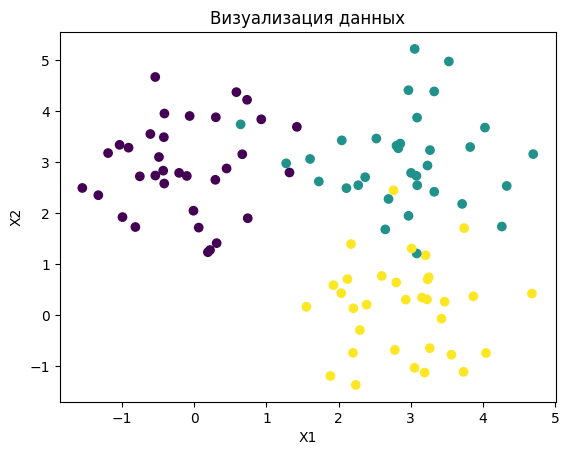

In [4]:
X, y = make_blobs(n_samples=100, centers=[(0,3),(3,3),(3,0)], 
                                      n_features=2, random_state=RANDOM_SEED,
                                      cluster_std=(0.9,0.9,0.9))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Визуализация данных')
plt.xlabel('X1')
plt.ylabel('X2')

In [ ]:
depth=4
clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=depth, 
                                  random_state=RANDOM_SEED)
clf_tree.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

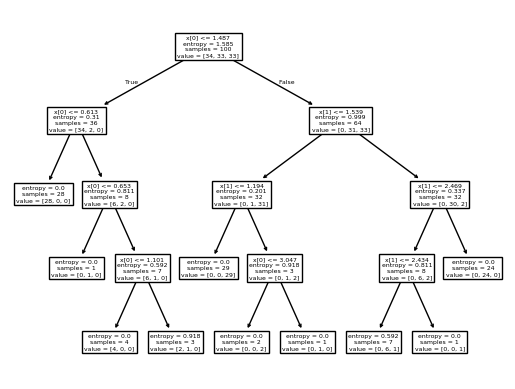

In [9]:

plot_tree(clf_tree)
plt.show()

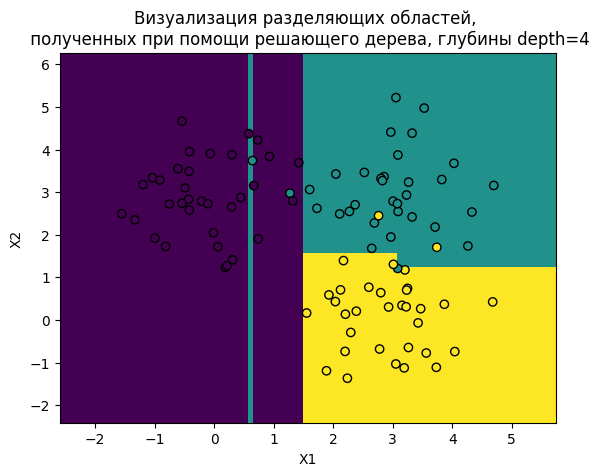

In [10]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_tree.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

plt.title('Визуализация разделяющих областей, \n полученных при помощи решающего дерева, глубины depth={}'.format(depth))
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [11]:
y_pred = clf_tree.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy =', accuracy_score(y, y_pred))
print('F1_score =', f1_score(y, y_pred, average='micro'))

[[34  0  0]
 [ 1 32  0]
 [ 0  1 32]]
Accuracy = 0.98
F1_score = 0.98


In [12]:
observation_new = [[2, 1]]

In [13]:
clf_tree.predict(observation_new)

array([2])

In [14]:
n_samples = 100
X = np.sort(np.random.rand(n_samples))
y = np.exp(X ** 2)+np.random.normal(0.0, 0.1, X.shape[0])

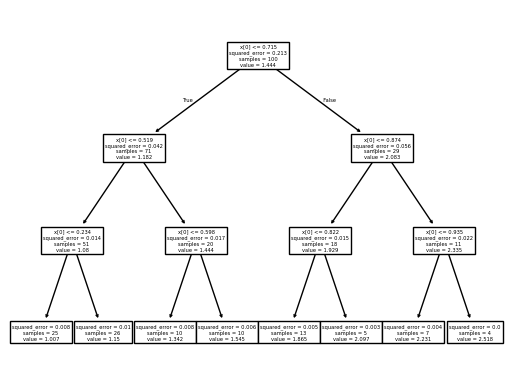

In [21]:
depth = 3
reg_tree = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_SEED)
X = X.reshape(-1, 1)          # <- добавляем эту строку
reg_tree.fit(X, y)
y_pred_reg = reg_tree.predict(X)

plot_tree(reg_tree)
plt.show()

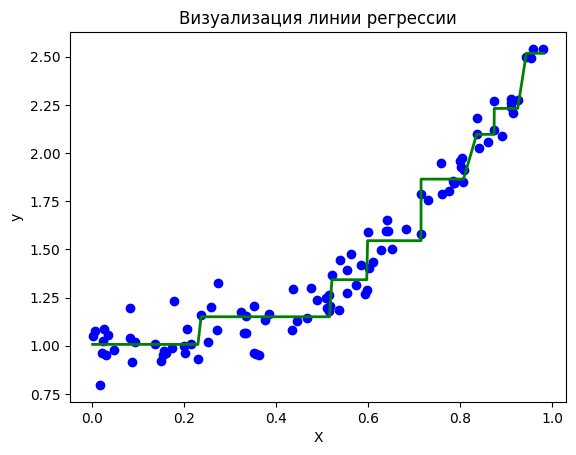

In [22]:
plt.scatter(X, y, c="b")

plt.plot(X, y_pred_reg, "g", lw=2)

plt.title('Визуализация линии регрессии')
plt.xlabel('X')
plt.ylabel('y');

In [23]:
print('r2= ', r2_score(y, y_pred_reg))
print('MSE= ', mean_squared_error(y, y_pred_reg))

r2=  0.966899599426967
MSE=  0.007056504281552414


In [24]:
observation_new = [[0.7]]

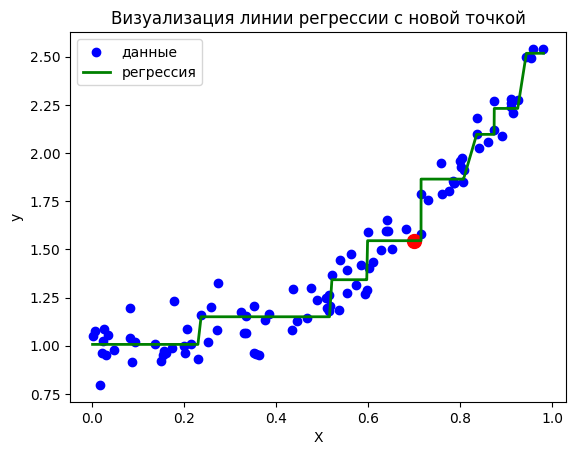

In [28]:
observation_new = [[0.7]]
pred_new = reg_tree.predict(observation_new)

plt.scatter(X, y, c="b", label='данные')
plt.plot(X, y_pred_reg, "g", lw=2, label='регрессия')
plt.scatter(observation_new, pred_new, c='r', s=100, marker='o', label='')
plt.legend()
plt.title('Визуализация линии регрессии с новой точкой')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

# Задание для самостоятельного решения

## Задания 1–5: Классификация на Iris

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
# Задание 1: только последние два столбца (длина и ширина лепестков)
X_ir2 = iris.data[:, 2:]
y_ir  = iris.target

plt.figure(figsize=(5, 4))
for c, name in enumerate(iris.target_names):
    plt.scatter(X_ir2[y_ir==c, 0], X_ir2[y_ir==c, 1], label=name, s=20)
plt.xlabel("petal length"); plt.ylabel("petal width")
plt.legend(); plt.title("Iris — два признака")
plt.show()

In [ ]:
# Задание 2: дерево глубины 4, entropy
clf_ir = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=RANDOM_SEED)
clf_ir.fit(X_ir2, y_ir)

plt.figure(figsize=(14, 5))
plot_tree(clf_ir, feature_names=["petal length", "petal width"],
          class_names=iris.target_names, filled=True, fontsize=8)
plt.title("Iris — дерево глубины 4")
plt.show()

In [ ]:
# Задания 3–4: разные глубины — границы + метрики
depths = [1, 2, 3, 4, 10]
xx, yy = np.meshgrid(np.linspace(X_ir2[:,0].min()-0.5, X_ir2[:,0].max()+0.5, 300),
                      np.linspace(X_ir2[:,1].min()-0.5, X_ir2[:,1].max()+0.5, 300))

fig, axes = plt.subplots(1, len(depths), figsize=(18, 3))
rows = []
for ax, d in zip(axes, depths):
    m = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=RANDOM_SEED).fit(X_ir2, y_ir)
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.pcolormesh(xx, yy, Z, alpha=0.3)
    for c in range(3):
        ax.scatter(X_ir2[y_ir==c, 0], X_ir2[y_ir==c, 1], s=10, label=iris.target_names[c])
    acc = accuracy_score(y_ir, m.predict(X_ir2))
    ax.set_title(f"depth={d}\nacc={acc:.2f}")
    rows.append({"depth": d, "accuracy": round(acc, 4),
                 "f1": round(f1_score(y_ir, m.predict(X_ir2), average='macro'), 4),
                 "leaves": m.get_n_leaves()})

plt.tight_layout(); plt.show()

df_depths = pd.DataFrame(rows).set_index("depth")
print(df_depths)
# Вывод: глубина 3–4 оптимальна; depth=10 переобучается (accuracy=1.0, но граница сложная).

In [ ]:
# Задание 5: полный Iris (4 признака)
X_ir_full = iris.data
clf_full = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=RANDOM_SEED)
clf_full.fit(X_ir_full, y_ir)

plt.figure(figsize=(16, 6))
plot_tree(clf_full, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True, fontsize=7)
plt.title("Iris full — дерево глубины 4")
plt.show()

yp_full = clf_full.predict(X_ir_full)
print(f"accuracy={accuracy_score(y_ir, yp_full):.4f}  f1={f1_score(y_ir, yp_full, average='macro'):.4f}")

## Задания 6–10: Регрессия на California Housing

In [ ]:
from sklearn.datasets import fetch_california_housing

ca = fetch_california_housing()
feat_idx = list(ca.feature_names).index('AveBedrms')

# Задание 6: один признак AveBedrms
X_ca1 = ca.data[:, feat_idx].reshape(-1, 1)
y_ca  = ca.target

plt.scatter(X_ca1, y_ca, s=2, alpha=0.3)
plt.xlabel("AveBedrms"); plt.ylabel("Price")
plt.title("California Housing — один признак")
plt.show()

In [ ]:
# Задание 7: регрессионное дерево (параметры по умолчанию, кроме random_state)
reg_ca = DecisionTreeRegressor(random_state=0).fit(X_ca1, y_ca)

In [ ]:
# Задание 8: граф дерева (ограничим глубину отображения) и кусочная регрессия
plt.figure(figsize=(14, 4))
plot_tree(reg_ca, max_depth=3, feature_names=["AveBedrms"], filled=True, fontsize=7)
plt.title("California Housing (1 признак) — дерево (показаны 3 уровня)")
plt.show()

# Кусочная линия регрессии
X_plot = np.linspace(X_ca1.min(), X_ca1.max(), 500).reshape(-1, 1)
plt.scatter(X_ca1, y_ca, s=2, alpha=0.3)
plt.plot(X_plot, reg_ca.predict(X_plot), 'r', lw=2)
plt.xlabel("AveBedrms"); plt.ylabel("Price")
plt.title("Кусочная регрессия (DecisionTreeRegressor)")
plt.show()

In [ ]:
# Задание 9: метрики + предсказание нового наблюдения
yp_ca1 = reg_ca.predict(X_ca1)
print(f"R²={r2_score(y_ca, yp_ca1):.4f}  MSE={mean_squared_error(y_ca, yp_ca1):.4f}")

new_obs = [[2.0]]  # среднее число спален
pred = reg_ca.predict(new_obs)[0]
print(f"Предсказание для AveBedrms={new_obs[0][0]}: {pred:.4f}")

plt.scatter(X_ca1, y_ca, s=2, alpha=0.3)
plt.plot(X_plot, reg_ca.predict(X_plot), 'r', lw=2)
plt.scatter(new_obs, [pred], c='orange', s=100, zorder=5, label='новое наблюдение')
plt.legend(); plt.xlabel("AveBedrms"); plt.ylabel("Price"); plt.show()

In [ ]:
# Задание 10: все 8 признаков California Housing
X_ca_full = ca.data
reg_full = DecisionTreeRegressor(random_state=0).fit(X_ca_full, y_ca)

# Граф (только верхние 3 уровня — полное дерево слишком велико)
plt.figure(figsize=(16, 5))
plot_tree(reg_full, max_depth=3, feature_names=ca.feature_names, filled=True, fontsize=7)
plt.title("California Housing (все признаки) — дерево (3 уровня)")
plt.show()

yp_full = reg_full.predict(X_ca_full)
print(f"R²={r2_score(y_ca, yp_full):.4f}  MSE={mean_squared_error(y_ca, yp_full):.4f}")
print(f"Глубина: {reg_full.get_depth()}  Листьев: {reg_full.get_n_leaves()}")